In [1]:
import json
import gzip
import glob
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
with gzip.open('D:\\ZeynepStudy\\MU_recordings\\MU_recordings\\v.smekal@maastrichtuniversity.nl\\2025-05-02_11-53-57\\MU_p40_02052025_0000_muscle.json.gz', 'rb') as f:
    data = json.load(f)
    
tracking_dict = {}

for i in range(len(data['bindings'])):
    tracking_dict[data['bindings'][i]['propertyName']] =  i
    print(data['bindings'][i]['propertyName'])

Spine Front-Back
Spine Left-Right
Spine Twist Left-Right
Chest Front-Back
Chest Left-Right
Chest Twist Left-Right
UpperChest Front-Back
UpperChest Left-Right
UpperChest Twist Left-Right
Neck Nod Down-Up
Neck Tilt Left-Right
Neck Turn Left-Right
Head Nod Down-Up
Head Tilt Left-Right
Head Turn Left-Right
Left Eye Down-Up
Left Eye In-Out
Right Eye Down-Up
Right Eye In-Out
Jaw Close
Jaw Left-Right
Left Upper Leg Front-Back
Left Upper Leg In-Out
Left Upper Leg Twist In-Out
Left Lower Leg Stretch
Left Lower Leg Twist In-Out
Left Foot Up-Down
Left Foot Twist In-Out
Left Toes Up-Down
Right Upper Leg Front-Back
Right Upper Leg In-Out
Right Upper Leg Twist In-Out
Right Lower Leg Stretch
Right Lower Leg Twist In-Out
Right Foot Up-Down
Right Foot Twist In-Out
Right Toes Up-Down
Left Shoulder Down-Up
Left Shoulder Front-Back
Left Arm Down-Up
Left Arm Front-Back
Left Arm Twist In-Out
Left Forearm Stretch
Left Forearm Twist In-Out
Left Hand Down-Up
Left Hand In-Out
Right Shoulder Down-Up
Right Should

In [10]:
bodyTrackingIndices = ['Head Nod Down-Up', 'Head Tilt Left-Right', 'Head Turn Left-Right', 'Left Arm Down-Up', 'Left Arm Front-Back', 'Left Arm Twist In-Out', 'Right Arm Down-Up', 'Right Arm Front-Back', 'Right Arm Twist In-Out']

d = {}

for index in bodyTrackingIndices:
    bodyPart = tracking_dict.get(index)
    
    partData = data['bindings'][bodyPart]['curve']
    partData= partData[0]
    
    partMovement = []
    times = []
    
    for t in range(len(partData)):
        time, change, a, b = partData[t]
        partMovement.append(change)
        times.append(time)
        
    d.update({index: partMovement})

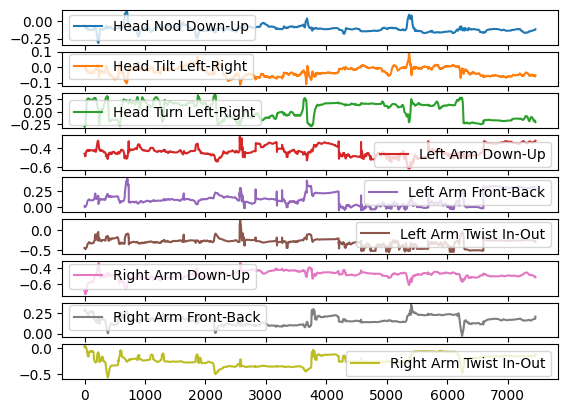

In [21]:
signals = pd.DataFrame(d)
fig = signals.plot(subplots=True)
movementPlot = fig[0].get_figure()
movementPlot.savefig("D:\\ZeynepStudy\\figures\\exampleBodyTracking.png", dpi=300)

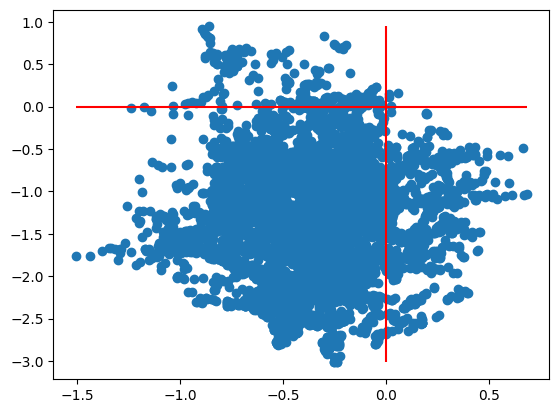

In [3]:
horizontal = 'Left Eye In-Out'
vertical = 'Left Eye Down-Up'
hindex = tracking_dict.get(horizontal)
vindex = tracking_dict.get(vertical)
    
hData = data['bindings'][hindex]['curve']
hData= hData[0]
vData = data['bindings'][vindex]['curve']
vData = vData[0]

horizontalMovement = []
verticalMovement = []

for t in range(len(hData)):
    time, change, a, b = hData[t]
    horizontalMovement.append(change)
    
    time, change, a, b = vData[t]
    verticalMovement.append(change)
    
xmin = min(horizontalMovement)
xmax = max(horizontalMovement)
ymin = min(verticalMovement)
ymax = max(verticalMovement)

plt.scatter(horizontalMovement, verticalMovement)
plt.hlines(y=0, xmin=xmin, xmax=xmax, colors='red')
plt.vlines(x=0, ymin=ymin, ymax=ymax, colors='red')

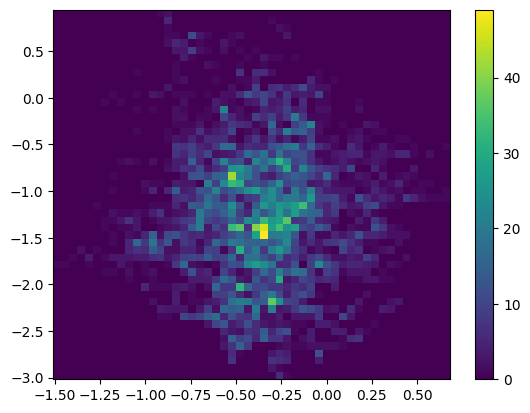

In [5]:
fig, ax = plt.subplots()
counts, xedges, yedges, im = ax.hist2d(horizontalMovement, verticalMovement, bins= (50, 50))
fig.colorbar(im, ax=ax)
plt.savefig("D:\\ZeynepStudy\\figures\\eyeMovementExample.png", dpi=300)

In [81]:
%matplotlib notebook

import matplotlib.animation as animation

fig, ax = plt.subplots()
ax.set(xlim=[xmin, xmax], ylim=[ymin, ymax])

scat = ax.scatter(horizontalMovement[0], verticalMovement[0])

def animate(frame):
    scat.set_offsets((horizontalMovement[frame], verticalMovement[frame]))
    return (scat,)

ani = animation.FuncAnimation(fig, animate, repeat=True, frames=len(horizontalMovement) -1, interval=30)
plt.show()

<IPython.core.display.Javascript object>

In [29]:
eye_df = pd.DataFrame(list(zip(horizontalMovement, verticalMovement)))

In [30]:
eye_df

,0,1
0,-0.144764,-1.096520
1,-0.172311,-1.102845
2,-0.281486,-1.130141
3,-0.396530,-1.160504
4,-0.383610,-1.139366
...,...,...
7113,-0.055415,-0.864991
7114,-0.062971,-0.788224
7115,-0.127298,-0.751624
7116,-0.147656,-0.752484


In [12]:
head_turn = 'UpperChest Twist Left-Right'

index = tracking_dict.get(head_turn)
    
headData = data['bindings'][index]['curve']
headData= headData[0]

headTurn = []
times = []

for t in range(len(headData)):
    time, change, a, b = headData[t]
    headTurn.append(change)
    times.append(time)

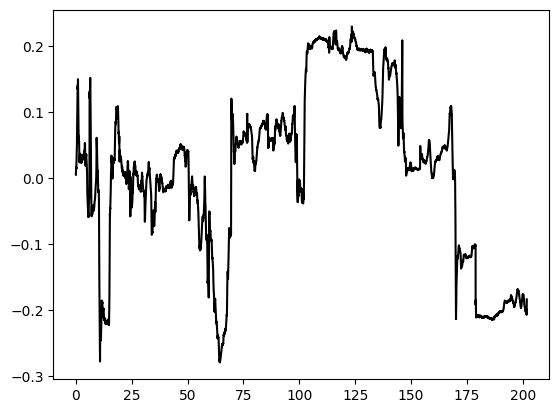

In [15]:
plt.plot(times, headTurn, 'k')
plt.savefig("D:\\ZeynepStudy\\figures\\bodyTrackingExample.png", dpi=300)

In [5]:
posHeadTurns = [abs(x) for x in headTurn]

In [93]:
sum(posHeadTurns)

1456.1930299196392

In [39]:
sessions = glob.glob("D:\\ZeynepStudy\\MU_recordings\\MU_recordings\\v.smekal@maastrichtuniversity.nl\\*")

In [40]:
participants = ["p03", "p04", "p05", "p06", "p08", "p09", "p10", "p12", "p13", "p14", "p18", "p19", "p20", "p21", "p22", "p23", "p24", "p25", "p26", "p27", "p28", "p29", "p31", "p32", "p33", "p34", "p35", "p36", "p37", "p38", "p39", "p40"]

validSessions = []
validParticipants = []

for s in sessions:
    currSession = glob.glob([s + "\\*"][0])
    
    if any(p in currSession[0] for p in participants):
        validSessions.append(s)
        
        for p in participants:
            if p in currSession[0]:
                validParticipants.append(p)

In [42]:
participantArray = []
conditionArray = []
headMovementArray = []

for idx, v in enumerate(validSessions):
    
    runs = glob.glob([v + "\\*muscle.json.gz"][0])
    
    prtcpnt = validParticipants[idx]
    
    condFile = f"D:\\ZeynepStudy\\DATA\\{prtcpnt}\\expConditions.json"
    
    with open(condFile, 'r') as file:
        expConditions = json.load(file)
        
    conditionOrder = expConditions['conditions_order']
    
    for r in range(len(runs)):
        with gzip.open(runs[r], 'rb') as f:
            data = json.load(f)
    
        tracking_dict = {}

        for i in range(len(data['bindings'])):
            tracking_dict[data['bindings'][i]['propertyName']] =  i
            
        head_turn = 'UpperChest Twist Left-Right'

        index = tracking_dict.get(head_turn)
            
        headData = data['bindings'][index]['curve']
        headData= headData[0]
        
        headTurn = []
        times = []
        
        for t in range(len(headData)):
            time, change, a, b = headData[t]
            headTurn.append(change)
            times.append(time)
            
        posHeadTurns = [abs(x) for x in headTurn]
        
        normHeadMovement = sum(posHeadTurns) / len(times)
        
        participantArray.append(prtcpnt)
        conditionArray.append(conditionOrder[r])
        headMovementArray.append(normHeadMovement)

In [43]:
df = pd.DataFrame(list(zip(participantArray, conditionArray, headMovementArray)), columns=['participant', 'condition', 'upperChest movement'])
df.loc[df['condition']==3, 'condition'] = 2
df.to_excel("D:\\ZeynepStudy\\dataAnalysis\\movementAnalysis\\upperChestTurn_socPres.xlsx", index=False)

In [45]:
df.groupby('condition')['upperChest movement'].mean()

condition
0    0.139553
1    0.124682
2    0.142046
Name: upperChest movement, dtype: float64

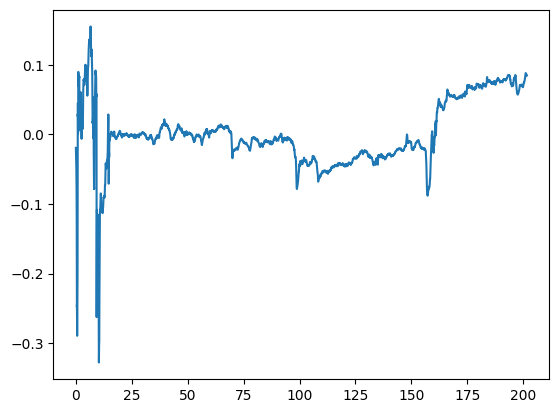

In [7]:
head_x = 'UpperChest Twist Left-Right'

index = tracking_dict.get(head_x)
    
headXData = data['bindings'][index]['curve']
headXData= headXData[0]

headXchange = []
times = []

for t in range(len(headXData)):
    time, change, a, b = headXData[t]
    headXchange.append(change)
    times.append(time)
    
plt.plot(times, headXchange)